<a href="https://colab.research.google.com/github/cavrinceanu/pyfun/blob/main/chmv2_dataset_download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download the Version 2 High Resolution Canopy Height Maps by WRI and Meta dataset

This notebook is based on the guided notebook for the [Version 2 High Resolution Canopy Height Maps by WRI and Meta](https://registry.opendata.aws/dataforgood-fb-forestsv2/) dataset.

> [!IMPORTANT]
> If attempting to download and mosaic a large number of tiles for a large area (e.g. country), it is best to use a high RAM environment. This is recommended for merging all tiles if possible.
> To do this, select **Runtime → Change runtime type**.

### Connect to a local drive for permanent storage:

In [1]:
#Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive




### Q: How is the dataset organised?
Helps with understanding the key prefix structure of the S3 bucket.



At the top level of our S3 bucket ("dataforgood-fb-data"), there is a prefix "forests/v2/global/dinov3_global_chm_v2_ml3" which contains:

 1. "chm" containing canopy height maps as cloud optimized geotiffs.
 2. "metadata" containing geojsons with observation date across the dataset.
 3. "tiles.geojson" is a geojson containing the tile extent for each tile, and the associated quadkey name.

 Full documentation for this dataset can be found at: https://arxiv.org/abs/2603.06382





### Setup
First we will import the Python libraries required throughout this notebook.

This notebook requires the following additional libraries
(please install using the preferred method for your environment, e.g. pip, conda):
<br>
 boto3 >= 1.38.23 <br>
 matplotlib >= 3.10.3 <br>
 rasterio >= 1.5.0 <br>
 geopandas >= 1.1.3 <br>
</br>

In [2]:
import time
!pip install boto3
print('boto3 installed')
time.sleep(5)
!pip install rasterio
print('rasterio installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 5.7 MB/s eta 0:00:00
boto3 installed /n
rasterio installed


In [3]:
# Built-ins
import json
from pprint import pprint
import tempfile
import os
# Installed libraries - AWS
import boto3, matplotlib.pyplot as plt
from botocore import UNSIGNED
from botocore.config import Config
#Installed libraries - Geo
import rasterio
import rasterio.mask
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import box
import geopandas as gp
import numpy as np
from osgeo import gdal

Next, define the location of our dataset, create a boto3 S3 client, and list the top level prefixes in the S3 path:


In [13]:
# Location of the S3 bucket for this dataset
bucket = "dataforgood-fb-data"
path = "forests/v2/global/dinov3_global_chm_v2_ml3/"

# List the top level of the bucket using boto3. Because this is a public bucket, there is no need to sign requests.
# Set the signature version to unsigned, which is required for public buckets.
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# Print the items in the top-level prefixes
for item in s3.list_objects_v2(Bucket=bucket, Prefix=path, Delimiter='/')['CommonPrefixes']:
    print(item['Prefix'])


forests/v2/global/dinov3_global_chm_v2_ml3/chm/
forests/v2/global/dinov3_global_chm_v2_ml3/metadata/




Looking into the geotiff prefix of our dataset, there is a list of .tif files, with names cooresponding to quadkey tiles at zoom_level=10.


In [14]:
path = "forests/v2/global/dinov3_global_chm_v2_ml3/"


# each page has a max of 1000 items
paginator = s3.get_paginator("list_objects_v2")
pages = paginator.paginate(Bucket=bucket, Prefix=path)

outlist = []
# only print first page here
for page in pages:
    if "Contents" in page.keys():
        objlist = [i["Key"] for i in page["Contents"]]
        outlist.extend(objlist)
        break
#we only print 10 here
pprint(outlist[-10:])

['forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222111.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222112.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222113.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222120.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222121.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222122.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222123.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222130.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222131.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222132.tif']




### Q: What data formats are present in the dataset? What kinds of data are stored using these formats?

The dataset comes as a set of Cloud Optimized Geotiffs:

-  The extent of each geotiff is a zoom_level=10 [web mercator tile](https://en.wikipedia.org/wiki/Web_Mercator_projection).
-  The filenames are quadkeys of the containing tile.
-  Each geotiff contains a single data band, which represents the top of canopy height above the ground in meters.
-  The mask band of the geotiff is a boolean represnting where or not the input imagery has been flagged as containing a cloud.
-  The CRS is epsg:3857


The geojsons contain a set of polygons in a given tile.
- Each polygon contains a single feature value, containing a string of the observation date of the input imagery.


### Downloading and loading data from the dataset



As an example to check the data, load up and look at one geotiff

In [15]:
# download one chm
s3file="forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222122.tif"
with tempfile.NamedTemporaryFile(suffix=".tif") as dst: #as temporary file no write on disk
    s3.download_file(bucket, s3file, dst.name)
    with rasterio.open(dst.name) as src:
        chm=src.read().squeeze()
        meta=src.meta
print(meta)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32768, 'height': 32768, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]'), 'transform': Affine(1.19432856695596, 0.0, -19880965.308861203,
       0.0, -1.1943285669557895, 10214432.96380467)}


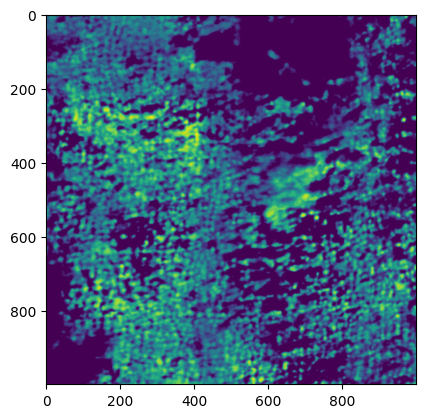

In [16]:
plt.imshow(chm[0:1000,0:1000])

### Setup local dir and AOIs

> [Important] First, create local folder on drive and upload the AOI files in geopackage format.

In [4]:
localdir='/content/drive/MyDrive/RightsLab/ENG_Canopy' # replace with local folder path

Define raster functions for an automated download of all tiles in an AOI

In [5]:
# Function to merge rasters
def merge_rasters(files, outfile: str = "aoi.tif") -> None:
    """
    Merge a list of geotiffs into one file
    """
    src_files_to_mosaic = []
    for fp in files:
        src = rasterio.open(fp)
        src_files_to_mosaic.append(src)

    crs = src.crs
    out_meta = src.meta.copy()
    mosaic, out_trans = merge(src_files_to_mosaic)

    # Update the metadata
    out_meta.update(
        {
            "driver": "GTiff",
            "height": mosaic.shape[1],
            "width": mosaic.shape[2],
            "transform": out_trans,
            "crs": crs,
        }
    )

    with rasterio.open(outfile, "w", **out_meta, compress="DEFLATE", BIGTIFF='YES') as dest:
        dest.write(mosaic)

#Function to use for high number of rasters
def merge_rasters_vrt(files: list, outfile: str = "aoi.tif") -> None:
    """
    Merge a list of GeoTIFFs into one file using a GDAL VRT as an intermediate step.
    Handles large numbers of files.
    """
    vrt_path = outfile.replace(".tif", ".vrt")

    # Build a VRT — a descriptor of tiles metadata without loading into memory
    vrt_options = gdal.BuildVRTOptions(resampleAlg="nearest", addAlpha=False)
    vrt = gdal.BuildVRT(vrt_path, files, options=vrt_options)
    vrt.FlushCache()  # Ensure the VRT is written to disk
    vrt = None        # Close the VRT object

    # Translate the VRT into a real GeoTIFF.
    translate_options = gdal.TranslateOptions(
        format="GTiff",
        creationOptions=[
            "COMPRESS=DEFLATE",   # Lossless compression
            "TILED=YES",          # Write in tiles (faster for large files)
            "BIGTIFF=YES",        # Support files > 4GB
            "NUM_THREADS=ALL_CPUS" # Parallelise compression
        ]
    )
    ds = gdal.Translate(outfile, vrt_path, options=translate_options)
    ds.FlushCache()
    ds = None

    # Flush the intermediate VRT
    if os.path.exists(vrt_path):
        os.remove(vrt_path)

    print(f"Merged {len(files)} rasters → {outfile}")


# Function to crop rasters

def crop_raster(rasterfile: str, aoi_gdf, outfile: str = "aoi.tif", nodata=255):
    #Copy gdf to avoid mutation
    gdf_aoi = aoi_gdf.copy()

    with rasterio.open(rasterfile) as src:
        out_meta = src.meta.copy()
        if src.crs.to_epsg() != gdf_aoi.crs.to_epsg():
            gdf_aoi = gdf_aoi.to_crs(src.crs)
        aoi = gdf_aoi.iloc[0].geometry
        im, trans = rasterio.mask.mask(
            src, [aoi], crop=True, nodata=nodata, all_touched=True
        )
        out_meta.update({
            "driver":    "GTiff",
            "height":    im.shape[1],
            "width":     im.shape[2],
            "transform": trans,
            "crs":       src.crs,
            "nodata":    nodata,
        })
    out_meta["compress"] = "deflate"
    out_meta["tiled"]    = True
    out_meta["bigtiff"]  = "YES"
    #Write raster
    with rasterio.open(outfile, "w", **out_meta) as dest:
        dest.write(im)


#Function to reproject to UTM
def get_utm_epsg(longitude: float, latitude: float) -> int:
    """Return the EPSG code for the UTM zone covering the given lon/lat."""
    zone_number = int((longitude + 180) / 6) + 1
    if latitude >= 0:
        return 32600 + zone_number  # Northern hemisphere
    return 32700 + zone_number  # Southern hemisphere


def get_utm_epsg(longitude: float, latitude: float) -> int:
    """Return the EPSG code for the UTM zone covering the given lon/lat.
    Expects longitude and latitude in decimal degrees (EPSG:4326).
    """
    zone_number = int((longitude + 180) / 6) + 1
    if latitude >= 0:
        return 32600 + zone_number  # Northern hemisphere
    return 32700 + zone_number      # Southern hemisphere


def reproject_to_utm(src_path: str, dst_path: str, resampling=Resampling.nearest) -> str:
    """Reproject a raster to the appropriate UTM zone.
    Handles rasters in any CRS, including EPSG:3857, by first converting
    bounds to EPSG:4326 to determine the correct UTM zone.

    Args:
        src_path:   Path to the input raster.
        dst_path:   Path for the output raster.
        resampling: Resampling method (default: nearest).

    Returns:
        The EPSG string of the destination UTM CRS (e.g. "EPSG:32630").
    """
    with rasterio.open(src_path) as src:
        # Transform bounds to 4326 — essential if source is 3857,
        # since UTM zone formula requires decimal degrees, not metres
        bounds_4326 = rasterio.warp.transform_bounds(
            src.crs, "EPSG:4326", *src.bounds
        )
        center_lon = (bounds_4326[0] + bounds_4326[2]) / 2
        center_lat = (bounds_4326[1] + bounds_4326[3]) / 2

        # Now safe to pass to UTM formula — these are degrees
        dst_epsg = get_utm_epsg(center_lon, center_lat)
        dst_crs  = f"EPSG:{dst_epsg}"

        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )

        kwargs = src.meta.copy()
        kwargs.update(
            crs=dst_crs,
            transform=transform,
            width=width,
            height=height,
            compress="deflate",
            tiled=True,
        )

        with rasterio.open(dst_path, "w", **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=resampling,
                )

    return dst_crs

chm geotiffs are tiled in web mercator tiles globally

In [27]:
#download polygons for global tiles
s3file=f'{path}tiles.geojson'
with tempfile.NamedTemporaryFile(suffix=".tif") as dst:
    s3.download_file(bucket, s3file, dst.name)
    s3_gdf = gp.read_file(dst.name)

Start from the UK countries

In [36]:
#Add UK countries
country_aoi_path= '/content/drive/MyDrive/RightsLab/ENG_Canopy/Countries_December_2021_UK_BUC_2022.gpkg'
country_aoi = gp.read_file(country_aoi_path, driver='GPKG')
country_aoi

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


,CTRY21CD,CTRY21NM,CTRY21NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E92000001,England,Lloegr,394883,370883,-2.07811,53.234970,{15BB8223-3421-462C-83FC-37997C1D8C0C},"MULTIPOLYGON (((400000 653913.865, 397934.594 ..."
1,N92000002,Northern Ireland,Gogledd Iwerddon,86544,535337,-6.85570,54.615009,{8F120662-6C39-45A0-9905-3D3959CB8B33},"MULTIPOLYGON (((116847.51 602929.172, 115611.5..."
2,S92000003,Scotland,Yr Alban,277744,700060,-3.97094,56.177429,{9EFC94D1-5CE7-47CE-BD1E-90386DEF28E5},"MULTIPOLYGON (((322071.699 973988.499, 321523...."
3,W92000004,Wales,Cymru,263405,242881,-3.99417,52.067410,{9C744C29-5982-4386-9676-F1EC0DAC6478},"MULTIPOLYGON (((312830.001 383662.642, 312525...."


EPSG:27700
EPSG:3857


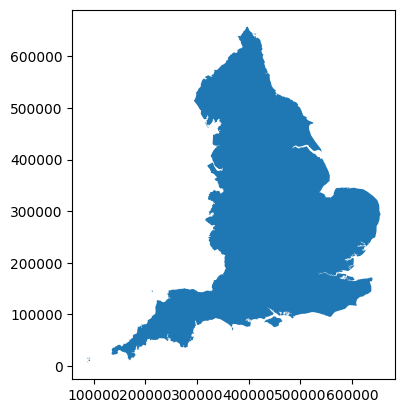

In [47]:
# Select only a single country
country = 'England'
aoi = country_aoi[country_aoi['CTRY21NM'] == country]
aoi.plot()
print(aoi.crs)
#Reproject
if aoi.crs.to_epsg() != 3857:
    aoi = aoi.to_crs(epsg=3857)
print(aoi.crs)

Optional: Start from processed, split country AOI

In [25]:
# Add AOI geopackage
'''aoi_path = os.path.join(localdir, 'england_3857.gpkg')
aoi = gp.read_file(aoi_path, driver='GPKG')
print (aoi.crs)

#Reproject
if aoi.crs.to_epsg() != 3857:
    aoi = aoi.to_crs(epsg=3857)
print(aoi.crs)

#Plot
aoi.plot()
'''

EPSG:3857


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


In [29]:
# Read the polygon
'''
target_polyfile=f'{localdir}/aoi_bbox.geojson' # use if reading from GeoJSON of AOI bbox
target=gp.read_file(target_polyfile)
tt=target.to_crs(s3_gdf.crs)  #tt= target tiles
'''
tt= aoi.to_crs(s3_gdf.crs) #tt= target tiles

In [30]:
# Find tile(s) that contain the target polygon
target_tiles=gp.sjoin(s3_gdf, tt)

In [32]:
target_tiles.head(2)

,tile,geometry,index_right,OBJECTID,CTRY21CD,CTRY21NM,CTRY21NMW,BNG_E,BNG_N,LONG,LAT,GlobalID
189,0313113201,"POLYGON ((-2.10938 53.12041, -2.10938 53.33087...",0,1,E92000001,England,Lloegr,394883,370883,-2.07811,53.23497,{15BB8223-3421-462C-83FC-37997C1D8C0C}
1053,0313113202,"POLYGON ((-2.46094 52.9089, -2.46094 53.12041,...",0,1,E92000001,England,Lloegr,394883,370883,-2.07811,53.23497,{15BB8223-3421-462C-83FC-37997C1D8C0C}


Download tiffs

In [33]:
tifs=[]
for ii, row in target_tiles.iterrows():
    print(row.tile)

    #download chm
    s3file=f"forests/v2/global/dinov3_global_chm_v2_ml3/chm/{row.tile}.tif"
    #Create directory for county
    if not os.path.exists(f"{localdir}/{country}"):
        os.makedirs(f"{localdir}/{country}")
    #Save local files
    localfile=f"{localdir}/{country}/{os.path.basename(s3file)}"
    if not os.path.exists(localfile):
        s3.download_file(bucket, s3file, localfile)

    tifs.append(localfile)

0313113201
0313113202
0313112133
0313131200
0313113203
0313111321
0313111300
0313112311
1202020011
0313111303
1202020101
0313111211
1202020102
0313112313
0313111212
0313111231
1202020013
0313131123
0313111213
0313113310
1202020120
0313111230
0313113122
0313131301
0313113312
0313131033
0313113300
0313131122
0313131032
0313131211
0313113302
0313130213
0313131210
1202020023
1202020210
1202020022
1202020032
0313111222
0313111001
1202020201
0313131133
1202020200
0313113000
0313111003
0313110332
0313131311
0313112110
0313113223
0313130312
0313112331
0313131202
0313113221
0313111323
0313130330
0313112333
0313113101
0313111233
1202020031
0313113010
0313113103
0313111232
0313113011
1202020033
0313131303
0313113330
0313131212
0313131110
0313131231
0313131321
0313113332
0313131213
0313131230
0313113322
0313111333
1202020212
0313113002
0313111021
0313113111
0313132011
1202020203
1202020230
0313113020
0313111023
1202020223
1202020202
0313131331
1202020221
1202020232
0313113022
0313111201
1202020220

Calculate the size on drive disk

In [34]:
#Calculate the disk size of all *tiff tiles in folder
total_size = sum(os.path.getsize(os.path.join(localdir, country, f)) for f in os.listdir(os.path.join(localdir, country)) if f.endswith('.tif'))
print(f"Total size of files in {country} dir: {total_size / (1024 * 1024 * 1024):.2f} GB")

Total size of files in /content/drive/MyDrive/RightsLab/ENG_Canopy: 20484.62 MB
Total size of files in /content/drive/MyDrive/RightsLab/ENG_Canopy: 20.00 GB


### Use a smaller AOI

In [6]:
counties_aoi = '/content/drive/MyDrive/RightsLab/ENG_Canopy/Counties_and_Unitary_Authorities_May_2023_UK_BGC.gpkg'
counties_aoi = gp.read_file(counties_aoi, driver='GPKG')
counties_aoi.head()

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


,CTYUA23CD,CTYUA23NM,CTYUA23NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E06000001,Hartlepool,,447160,531474,-1.27018,54.676102,{3BF43124-F19B-410C-A4D7-FE936CD94D88},"MULTIPOLYGON (((447097.001 537152.001, 446953...."
1,E06000002,Middlesbrough,,451141,516887,-1.21099,54.544701,{F97DE8D7-F645-4919-8499-EAC4F1FA02E0},"MULTIPOLYGON (((449862.75 521262.4, 449381.8 5..."
2,E06000003,Redcar and Cleveland,,464361,519597,-1.00608,54.567501,{EF76D83C-4B2E-4415-8A89-7BBE66AD618F},"MULTIPOLYGON (((455939.672 527395.073, 455853...."
3,E06000004,Stockton-on-Tees,,444940,518183,-1.30664,54.556900,{05FC23F8-570F-46F2-B175-CE60859DA82C},"MULTIPOLYGON (((444126.099 528005.799, 444064...."
4,E06000005,Darlington,,428029,515648,-1.56835,54.535301,{5A21326C-3C88-467D-82DE-941423F4745E},"MULTIPOLYGON (((423475.701 524731.597, 423296...."


In [7]:
#Create a list of all CTYUA23NM to check names
counties = counties_aoi['CTYUA23NM'].unique()
print(counties)

['Hartlepool' 'Middlesbrough' 'Redcar and Cleveland' 'Stockton-on-Tees'
 'Darlington' 'Halton' 'Warrington' 'Blackburn with Darwen' 'Blackpool'
 'Kingston upon Hull, City of' 'East Riding of Yorkshire'
 'North East Lincolnshire' 'North Lincolnshire' 'York' 'Derby' 'Leicester'
 'Rutland' 'Nottingham' 'Herefordshire, County of' 'Telford and Wrekin'
 'Stoke-on-Trent' 'Bath and North East Somerset' 'Bristol, City of'
 'North Somerset' 'South Gloucestershire' 'Plymouth' 'Torbay' 'Swindon'
 'Peterborough' 'Luton' 'Southend-on-Sea' 'Thurrock' 'Medway'
 'Bracknell Forest' 'West Berkshire' 'Reading' 'Slough'
 'Windsor and Maidenhead' 'Wokingham' 'Milton Keynes' 'Brighton and Hove'
 'Portsmouth' 'Southampton' 'Isle of Wight' 'County Durham'
 'Cheshire East' 'Cheshire West and Chester' 'Shropshire' 'Cornwall'
 'Isles of Scilly' 'Wiltshire' 'Bedford' 'Central Bedfordshire'
 'Northumberland' 'Bournemouth, Christchurch and Poole' 'Dorset'
 'Buckinghamshire' 'North Northamptonshire' 'West Northampton

We can see that counties and cities are separate.
<br>
Example: Nottingham and Nottinghamshire
<br>
This download uses Nottinghamshire

In [8]:
county = 'Nottinghamshire'

EPSG:27700
EPSG:3857


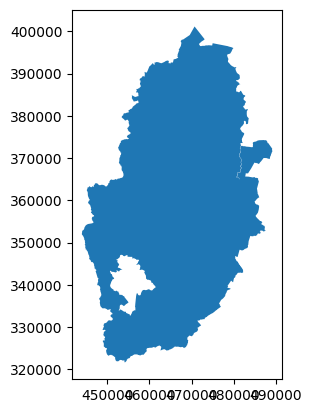

In [9]:
county_aoi= counties_aoi[counties_aoi['CTYUA23NM'] == county]
county_aoi.plot()
print(county_aoi.crs)
#Reproject
if county_aoi.crs.to_epsg() != 3857:
    county_aoi = county_aoi.to_crs(epsg=3857)
print(county_aoi.crs)

In [55]:
#Create target tiles for the local file
tt_local= county_aoi.to_crs(s3_gdf.crs)
target_tiles_local = target_tiles=gp.sjoin(s3_gdf, tt_local)
target_tiles.head(2)

,tile,geometry,index_right,CTYUA23CD,CTYUA23NM,CTYUA23NMW,BNG_E,BNG_N,LONG,LAT,GlobalID
11519,0313113310,"POLYGON ((-0.35156 53.12041, -0.35156 53.33087...",145,E10000024,Nottinghamshire,,466570,359496,-1.00656,53.128502,{79C55554-FAD5-4089-A9C9-8A250FC133EF}
12440,0313113122,"POLYGON ((-1.05469 53.33087, -1.05469 53.54031...",145,E10000024,Nottinghamshire,,466570,359496,-1.00656,53.128502,{79C55554-FAD5-4089-A9C9-8A250FC133EF}


In [57]:
tifs=[]
for ii, row in target_tiles_local.iterrows():
    print(row.tile)

    #download chm
    s3file=f"forests/v2/global/dinov3_global_chm_v2_ml3/chm/{row.tile}.tif"
    #Create directory for county
    if not os.path.exists(f"{localdir}/{county}"):
        os.makedirs(f"{localdir}/{county}")
    #Save local files
    localfile=f"{localdir}/{county}/{os.path.basename(s3file)}"
    if not os.path.exists(localfile):
        s3.download_file(bucket, s3file, localfile)

    tifs.append(localfile)

0313113310
0313113122
0313113312
0313113300
0313113302
0313113123
0313113301
0313113303
0313113321
0313113320


In [60]:
# Check disk size
#Calculate the disk size of all *tiff tiles in folder
total_size = sum(os.path.getsize(os.path.join(localdir, county, f)) for f in os.listdir(os.path.join(localdir, county)) if f.endswith('.tif'))
print(f"Total size of files in {county} dir: {total_size / (1024 * 1024):.2f} MB")
print(f"Total size of files in {county} dir: {total_size / (1024 * 1024 * 1024):.2f} GB")

Total size of files in /content/drive/MyDrive/RightsLab/ENG_Canopy: 744.71 MB
Total size of files in /content/drive/MyDrive/RightsLab/ENG_Canopy: 0.73 GB


Create a mosaic of all tiles

In [10]:
#Optional: if the previous step was interrupted
#Create a temporary tifs list from the *tiffs in the localdir

# List all .tif files in the country directory
#tifs = [os.path.join(localdir, country, f) for f in os.listdir(os.path.join(localdir, country)) if f.endswith('.tif')]

# List all .tif files in the county directory
tifs = [os.path.join(localdir, county, f) for f in os.listdir(os.path.join(localdir, county)) if f.endswith('.tif')]

> [!Important] Choose between the merge_rasters or merge_rasters_vrt functions depending on the number of tiles downloaded to avoid memory issues. If attempting to mosaic a large number of tiles, it is best to change the Runtime to a high computing RAM environment. In general, this is recommended for merging all tiles if possible. To do this, select **Runtime -> Change runtime type** and run the previous cell to make sure the list of tiles in folder is reconstructed.

In [12]:
#merge all tile tiffs into one continuous tif
#mergefile=f"{localdir}/{country}/{country}_alltiles.tif" #for country
mergefile=f"{localdir}/{county}/{county}_alltiles.tif"  #for county
if not os.path.exists(mergefile):
    merge_rasters_vrt(tifs, outfile=mergefile)

> [Note]: execution time is about 10 minutes for a small county

Reproject to UTM for Equal Area (optional)

In [13]:
#reproject to utm for equal area meter pixels
utmfile=mergefile.replace(f'{county}_alltiles.tif', f'{county}_utm.tif')
if not os.path.exists(utmfile):
    utm_crs=reproject_to_utm(mergefile, utmfile)

Crop mosaic to bounds

In [ ]:
#Add aoi path if not from folder
#aoi_path=f'{localdir}/aoi.geojson'

<Axes: >

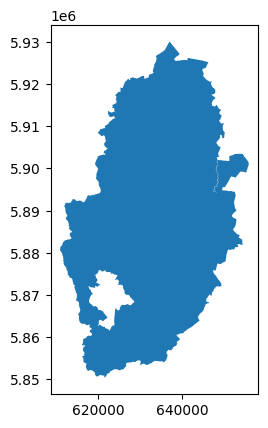

In [17]:
#Calculate UTM zone for county AOI if using the UTM file to crop
#EPSG:32630 for England UTM - the lazy way
county_aoi_utm=county_aoi.to_crs('epsg:32630')
county_aoi_utm.plot()

In [21]:
#crop to bounds of input polygon
#cropfile=utmfile.replace(f'{county}_utm.tif', f'{county}_crop_utm.tif') #replace to mergefile and _alltiles if not using the UTM file
cropfile=mergefile.replace(f'{county}_alltiles.tif', f'{county}_crop.tif')
if not os.path.exists(cropfile):
    crop_raster(mergefile, county_aoi, cropfile) #replace with aoi_path; replace to county_aoi if using the mergefile